In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zeeshier/weather-forecast-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'weather-forecast-dataset' dataset.
Path to dataset files: /kaggle/input/weather-forecast-dataset


In [ ]:
import os
print(os.listdir(path))

['weather_forecast_data.csv']


In [ ]:
import pandas as pd
df = pd.read_csv(path + "/weather_forecast_data.csv")
print(df.head())

   Temperature   Humidity  Wind_Speed  Cloud_Cover     Pressure     Rain
0    23.720338  89.592641    7.335604    50.501694  1032.378759     rain
1    27.879734  46.489704    5.952484     4.990053   992.614190  no rain
2    25.069084  83.072843    1.371992    14.855784  1007.231620  no rain
3    23.622080  74.367758    7.050551    67.255282   982.632013     rain
4    20.591370  96.858822    4.643921    47.676444   980.825142  no rain


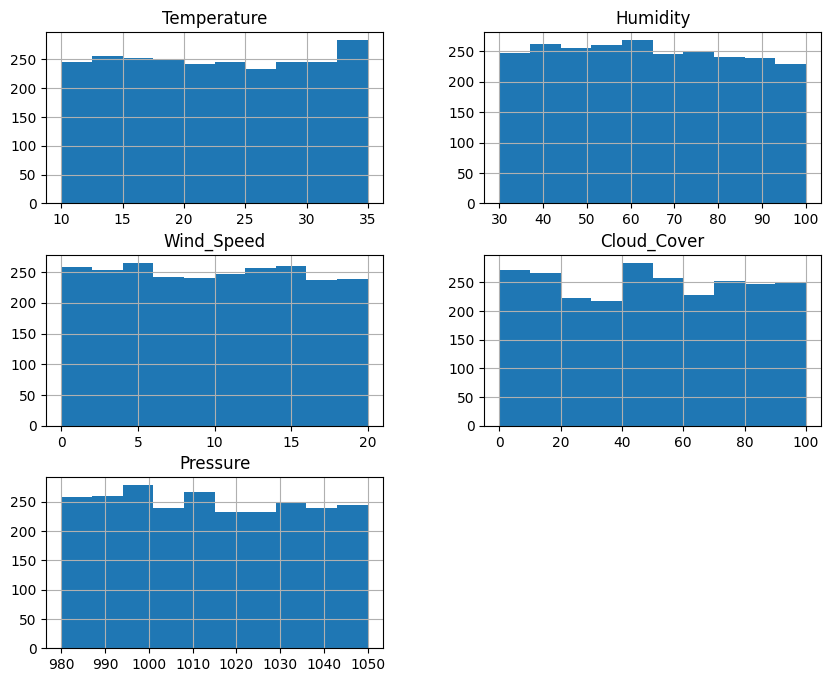

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()

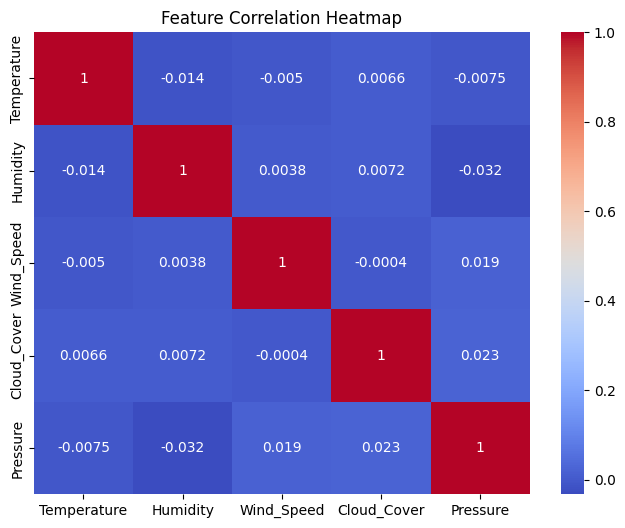

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

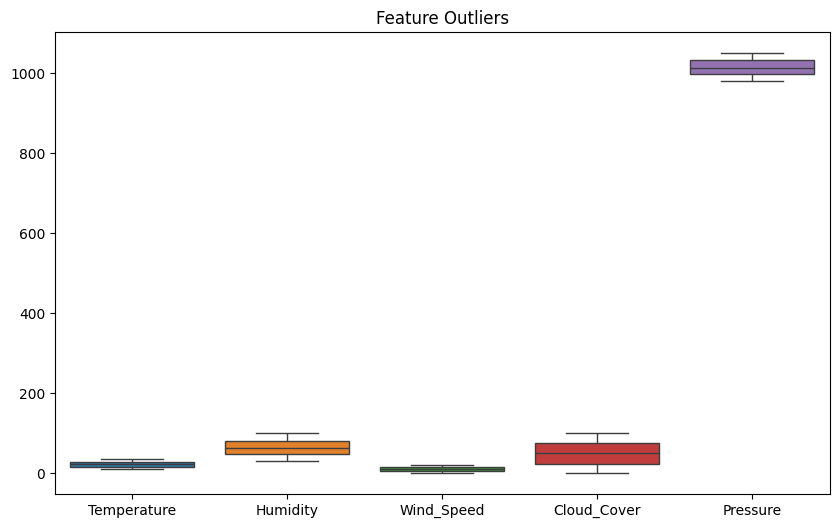

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df.drop('Rain', axis=1))

plt.title("Feature Outliers")

plt.show()

In [ ]:
df['Rain'] = df['Rain'].map({
    'no rain':0,
    'rain':1
})

In [ ]:
df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,1
1,27.879734,46.489704,5.952484,4.990053,992.614190,0
2,25.069084,83.072843,1.371992,14.855784,1007.231620,0
3,23.622080,74.367758,7.050551,67.255282,982.632013,1
4,20.591370,96.858822,4.643921,47.676444,980.825142,0


In [ ]:
X = df.drop('Rain', axis=1)
y = df['Rain']

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

   Temperature  Humidity  Wind_Speed  Cloud_Cover  Pressure
0     0.548885  0.851343    0.366485     0.504954  0.748370
1     0.715305  0.235520    0.297292     0.049759  0.180070
2     0.602850  0.758193    0.068145     0.148433  0.388977
3     0.544954  0.633821    0.352225     0.672518  0.037409
4     0.423693  0.955157    0.231829     0.476696  0.011586


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)

(2000, 5)


In [ ]:
import numpy as np

X_train = np.array(X_train)
X_test = np.array(X_test)

X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [ ]:
print(X_train.shape)

(2000, 1, 5)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
model = Sequential()

model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

Epoch 1/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9545 - loss: 0.0998 - val_accuracy: 0.9660 - val_loss: 0.0981
Epoch 2/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9565 - loss: 0.0984 - val_accuracy: 0.9700 - val_loss: 0.0971
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9550 - loss: 0.0962 - val_accuracy: 0.9660 - val_loss: 0.0985
Epoch 4/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9545 - loss: 0.1027 - val_accuracy: 0.9640 - val_loss: 0.0985
Epoch 5/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9560 - loss: 0.0967 - val_accuracy: 0.9660 - val_loss: 0.0957
Epoch 6/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9535 - loss: 0.1054 - val_accuracy: 0.9700 - val_loss: 0.0960
Epoch 7/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9545 - loss: 0.1002 - val_accuracy: 0.9660 - val_loss: 0.0971
Epoch 8/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9505 - loss: 0.1043 - val_accuracy: 0.9680 - v

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9800 - loss: 0.0574 
Test Accuracy: 0.9800000190734863


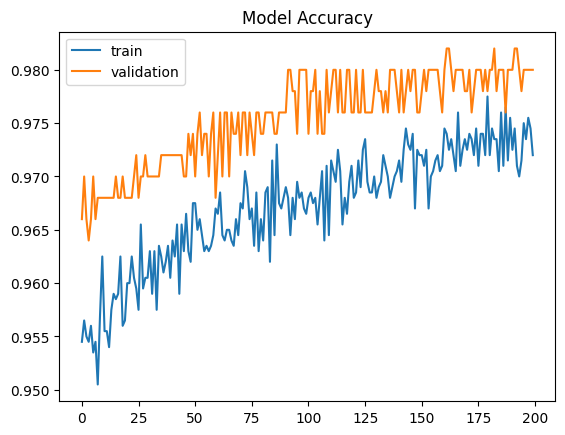

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')

plt.title("Model Accuracy")
plt.legend()

plt.show()